In [84]:
from kaggle_environments import make

env = make('connectx')

rows = env.configuration.rows
columns = env.configuration.columns
inarow = env.configuration.inarow

assert rows == 6
assert columns == 7
assert inarow == 4

In [85]:
import torch
import numpy as np
import os

def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(42)

In [86]:
class My_DQN(torch.nn.Module):
    def __init__(self, env_config, my_config, device='cpu'):
        super().__init__()
        self.env_config = env_config

        self.model = torch.nn.Sequential(
            torch.nn.Linear(env_config.rows * env_config.columns, my_config.h, device=device),
            torch.nn.ReLU(),
            torch.nn.Linear(my_config.h, my_config.h, device=device),
            torch.nn.ReLU(),
            torch.nn.Linear(my_config.h, my_config.h, device=device),
            torch.nn.ReLU(),
            torch.nn.Linear(my_config.h, env_config.columns, device=device)
        )

    def forward(self, X):
        assert X.shape[-1] == self.env_config.rows * self.env_config.columns
        return self.model(X.to(dtype=torch.float32))


In [87]:
from types import SimpleNamespace

device = 'cuda'
env_config = env.configuration
my_config = SimpleNamespace(
    h=128
)

Q_func = My_DQN(env_config, my_config, device)

In [88]:
Y = Q_func(torch.ones(5, 42, device=device))
print(Y)

tensor([[-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062]],
       device='cuda:0', grad_fn=<AddmmBackward0>)


---


Initialize replay memory $D$ to capacity $N$

Initialize action-value function $Q$ with random weights $\theta$

Initialize target action-value function $\hat{Q}$ with weights $\theta^- = \theta$

**For** episode $= 1, M$ **do**

$\quad$ Initialize sequence $s_1 = \{x_1\}$ and preprocessed sequence $\phi_1 = \phi(s_1)$

$\quad$ **For** $t = 1, T$ **do**

$\qquad$ With probability $\varepsilon$ select a random action $a_t$

$\qquad$ otherwise select $a_t = \text{argmax}_a Q(\phi(s_t), a; \theta)$

$\qquad$ Execute action $a_t$ in emulator and observe reward $r_t$ and image $x_{t+1}$

$\qquad$ Set $s_{t+1} = s_t, a_t, x_{t+1}$ and preprocess $\phi_{t+1} = \phi(s_{t+1})$

$\qquad$ Store transition $(\phi_t, a_t, r_t, \phi_{t+1})$ in $D$

$\qquad$ Sample random minibatch of transitions $(\phi_j, a_j, r_j, \phi_{j+1})$ from $D$

$\qquad$ Set $y_j = \begin{cases} r_j & \text{if episode terminates at step } j+1 \\ r_j + \gamma \max_{a'} \hat{Q}(\phi_{j+1}, a'; \theta^-) & \text{otherwise} \end{cases}$

$\qquad$ Perform a gradient descent step on $\left(y_j - Q(\phi_j, a_j; \theta)\right)^2$ with respect to the network parameters $\theta$

$\qquad$ Every $C$ steps reset $\hat{Q} = Q$

$\quad$ **End For**

**End For**

In [90]:
def process_state(obs, device='cpu'):
    board = torch.tensor(obs.board, device=device)

    opponent_mark = 1 if obs.mark == 1 else 2
    board[board==opponent_mark] = -1
    board[board==obs.mark] == 1

    return board

class Memory:
    def __init__(self, env_config, train_config, device='cpu'):
        self.train_config = train_config

        self.state = torch.zeros(
            train_config.total_steps, 
            env_config.rows * env_config.columns,
            device=device
        )
        self.action = torch.zeros(train_config.total_steps, device=device, dtype=torch.int64)
        self.reward = torch.zeros(train_config.total_steps, device=device)
        self.next_state = torch.zeros(
            train_config.total_steps, 
            env_config.rows * env_config.columns,
            device=device
        )
        self.done = torch.zeros(train_config.total_steps, device=device, dtype=bool)

        self._at = 0

    def __len__(self):
        return self._at

    def write(self, state, action, reward, next_state, done):
        at = self._at
        self.state[at] = state
        self.action[at] = action
        self.reward[at] = reward
        self.next_state[at] = next_state
        self.done[at] = done

        self._at += 1
        
    def sample_minibatch(self):
        idx = torch.randperm(self._at)[:self.train_config.batch_size]

        return (
            self.state[idx],
            self.action[idx],
            self.reward[idx],
            self.next_state[idx],
            self.done[idx]
        )

In [91]:
train_config = SimpleNamespace(
    batch_size = 32,
    total_steps = 10000,
    epsilon = 0.1, # ???
    reward_for_None = -5
)

In [92]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR

optimizer = AdamW(Q_func.parameters())
scheduler = LinearLR(
    optimizer, 
    start_factor=0.1, 
    end_factor=1, 
    total_iters=(train_config.total_steps - 2 * train_config.batch_size) / 2)

In [93]:
logs = {'loss': [], 'lr': []}
memory = Memory(env_config, train_config, device)

Q_func_hat = My_DQN(env_config, my_config, device)
Q_func_hat.load_state_dict(Q_func.state_dict())

Q_func.train()
Q_func_hat.eval()

trainer = env.train([None, 'random'])
done = False
obs = trainer.reset()
state = process_state(obs, device)

for step in range(train_config.total_steps):
    print('step:', step)
    if torch.rand(1) <= train_config.epsilon:
        action = int(np.random.choice(
            [c for c in range(env_config.columns) if state[c] == 0]
        ))
    else:
        action = Q_func(state[None,:]).argmax(dim=-1).item()

    obs, reward, done, _ = trainer.step(action)
    next_state = process_state(obs, device)
    if reward is None: reward = train_config.reward_for_None

    memory.write(state, action, reward, next_state, done)

    if len(memory) >= train_config.batch_size * 2: # ???
        states, actions, rewards, next_states, dones = memory.sample_minibatch()
        
        with torch.no_grad():
            target_rewards = rewards + Q_func_hat(next_states).max(dim=-1).values * ~dones
        pred_rewards = Q_func(states)[torch.arange(train_config.batch_size, device=device),actions]

        loss = (1 / train_config.batch_size) * torch.square(target_rewards - pred_rewards).sum()
        logs['loss'].append(loss.item())
        logs['lr'].append(optimizer.param_groups[0]['lr'])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

    if done:
        obs = trainer.reset()
        state = process_state(obs, device)
    else:
        state = next_state

step: 0
step: 1
step: 2
step: 3
step: 4
step: 5
step: 6
step: 7
step: 8
step: 9
step: 10
step: 11
step: 12
step: 13
step: 14
step: 15
step: 16
step: 17
step: 18
step: 19
step: 20
step: 21
step: 22
step: 23
step: 24
step: 25
step: 26
step: 27
step: 28
step: 29
step: 30
step: 31
step: 32
step: 33
step: 34
step: 35
step: 36
step: 37
step: 38
step: 39
step: 40
step: 41
step: 42
step: 43
step: 44
step: 45
step: 46
step: 47
step: 48
step: 49
step: 50
step: 51
step: 52
step: 53
step: 54
step: 55
step: 56
step: 57
step: 58
step: 59
step: 60
step: 61
step: 62
step: 63
step: 64
step: 65
step: 66
step: 67
step: 68
step: 69
step: 70
step: 71
step: 72
step: 73
step: 74
step: 75
step: 76
step: 77
step: 78
step: 79
step: 80
step: 81
step: 82
step: 83
step: 84
step: 85
step: 86
step: 87
step: 88
step: 89
step: 90
step: 91
step: 92
step: 93
step: 94
step: 95
step: 96
step: 97
step: 98
step: 99
step: 100
step: 101
step: 102
step: 103
step: 104
step: 105
step: 106
step: 107
step: 108
step: 109
step: 110


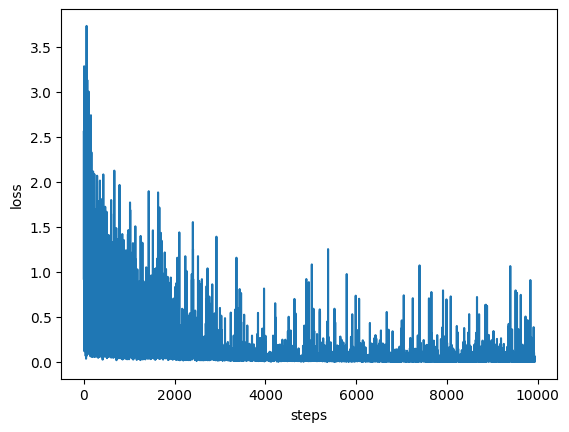

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(x=range(len(logs['loss'])), y=logs['loss'])
plt.xlabel('steps')
plt.ylabel('loss')
plt.show()

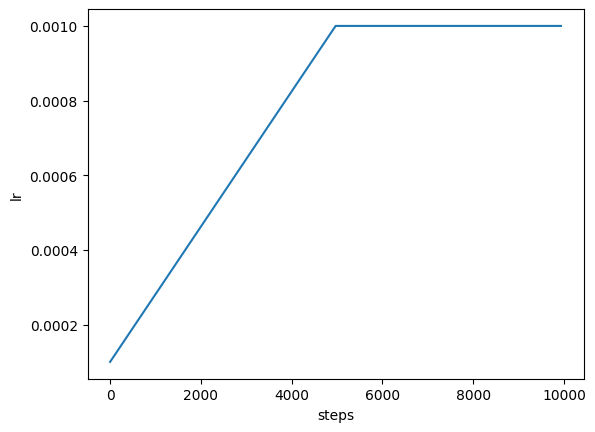

In [95]:
sns.lineplot(x=range(len(logs['lr'])), y=logs['lr'])
plt.xlabel('steps')
plt.ylabel('lr')
plt.show()

---

## Validate:

In [103]:
A = torch.tensor([1, 2, 3], dtype=torch.float32)
B = torch.tensor([1, 2, 3])

A[B != 0] = -float('inf')
print(A.argmax().item())

0


In [131]:
def my_agent(obs, config):
    assert config.rows == 6
    assert config.columns == 7
    assert config.inarow == 4

    moves = Q_func(process_state(obs, device)[None,:])[0]
    mask_board = torch.tensor(obs.board[:config.columns], dtype=bool, device=device)

    action = torch.masked_fill(moves, mask_board, -float('inf')).argmax().item()
    print('action:', action)
    return action


In [157]:
from kaggle_environments import evaluate

def mean_reward(rewards):
    return sum(r[0] for r in rewards) / float(len(rewards))

# Run multiple episodes to estimate its performance.
# print("My Agent vs Random Agent:", mean_reward(evaluate("connectx", [my_agent, "random"], num_episodes=100)))
print("My Agent vs Negamax Agent:", mean_reward(evaluate("connectx", [my_agent, "negamax"], num_episodes=100)))

My Agent vs Negamax Agent: -0.92
